# Credit Card Fraud Detection – Finance ML Project



---

## Project Overview

In this project, we work with the **Credit Card Fraud Detection** dataset from Kaggle
The dataset contains anonymized credit card transactions made by European cardholders in September 2013.  
The goal is to build **machine learning models** that can distinguish between legitimate and fraudulent transactions.

Because fraud is **very rare** (highly imbalanced classes), this is a realistic **finance / risk modeling** problem and a good example of how machine learning is used in financial institutions.


## Original Kaggle Project Reference

- **Dataset:** [Credit Card Fraud Detection – Kaggle](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)
- **Original Notebook (baseline project):** [Credit card Fraud detection analysis](https://www.kaggle.com/code/neharoychoudhury/credit-card-fraud-detection-analysis)

The original notebook performs:
- Exploratory data analysis (EDA)
- Inspection of class imbalance (fraud vs non-fraud)
- Train/test split
- Training at least one classification model (Logistic Regression) and evaluating with accuracy/recall/precision.

---

Below, Part 1 reproduces the **core ideas** of the original project.  
Part 2 contains **my own extensions**, which go beyond the original analysis.


# Part 1 – Reproducing the Original Analysis

In this section, we follow the same general workflow as the original Kaggle notebook:

1. Load and inspect the dataset.
2. Explore basic statistics and class imbalance.
3. Build a baseline Logistic Regression model.
4. Evaluate performance with common classification metrics.


In [1]:
# Part 1 – Imports
# Import core libraries for data analysis and machine learning
import pandas as pd  # data manipulation
import numpy as np   # numerical operations

import matplotlib.pyplot as plt  # plotting
import seaborn as sns           # nicer visualizations

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)

pd.set_option('display.max_columns', None)


In [2]:
%%bash

KAGGLE_USERNAME="ranphyreyes"
KAGGLE_KEY="2a44ccc09f77aef8780010fe91daa1c9"

OUTPUT_DIR="$HOME/Downloads"
ZIP_PATH="$OUTPUT_DIR/creditcardfraud.zip"

echo ">>> Checking output directory..."
mkdir -p "$OUTPUT_DIR"

echo ">>> Downloading Credit Card Fraud dataset from Kaggle..."
curl -L \
  -u $KAGGLE_USERNAME:$KAGGLE_KEY \
  -o "$ZIP_PATH" \
  "https://www.kaggle.com/api/v1/datasets/download/mlg-ulb/creditcardfraud"

#  3. Check download success
if [ $? -ne 0 ]; then
  echo "❌ Download failed. Likely reasons:"
  echo "   • Wrong username or key"
  echo "   • Dataset license not accepted on Kaggle"
  echo "   • Network blocked"
  exit 1
fi

echo ">>> Download complete: $ZIP_PATH"

echo ">>> Unzipping dataset..."
unzip -o "$ZIP_PATH" -d "$OUTPUT_DIR"

if [ $? -ne 0 ]; then
  echo "❌ Unzip failed."
  exit 1
fi

echo ">>> Done!"
echo "Dataset extracted to: $OUTPUT_DIR"
echo "File should now exist: $OUTPUT_DIR/creditcard.csv"


>>> Checking output directory...
>>> Downloading Credit Card Fraud dataset from Kaggle...
>>> Download complete: /root/Downloads/creditcardfraud.zip
>>> Unzipping dataset...
Archive:  /root/Downloads/creditcardfraud.zip
  inflating: /root/Downloads/creditcard.csv  
>>> Done!
Dataset extracted to: /root/Downloads
File should now exist: /root/Downloads/creditcard.csv


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 65.9M  100 65.9M    0     0  38.5M      0  0:00:01  0:00:01 --:--:--  180M


In [3]:
data_path = '/root/Downloads/creditcard.csv'
df = pd.read_csv(data_path)
display(df.head())

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
# Basic info and summary statistics
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
# Summary statistics: note that most features are already PCA-transformed (V1..V28)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [6]:
# Check missing values
df.isna().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [7]:
# Examine class distribution (0 = non-fraud, 1 = fraud)
class_counts = df['Class'].value_counts()
class_counts

,count
Class,
0,284315
1,492


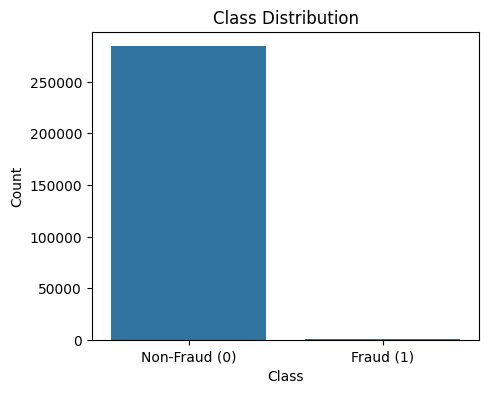

In [8]:
# Visualize class imbalance
plt.figure(figsize=(5,4))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.xticks([0, 1], ['Non-Fraud (0)', 'Fraud (1)'])
plt.title('Class Distribution')
plt.ylabel('Count')
plt.show()


We can see that the dataset is **extremely imbalanced**: only a tiny fraction of transactions are labeled as fraud.  
This is typical in finance (fraud detection, default prediction, etc.) and creates challenges for machine learning models.


In [9]:
# Feature/target split
X = df.drop('Class', axis=1)
y = df['Class']

# Train-test split (keeping class distribution with stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape

((227845, 30), (56962, 30))

In [10]:
# Baseline Logistic Regression model (similar to original project)

log_reg = LogisticRegression(max_iter=1000, n_jobs=-1)
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)
y_proba = log_reg.predict_proba(X_test)[:, 1]

print("Classification Report (Baseline Logistic Regression):")
print(classification_report(y_test, y_pred, digits=4))

baseline_auc = roc_auc_score(y_test, y_proba)
print(f"Baseline ROC-AUC: {baseline_auc:.4f}")


Classification Report (Baseline Logistic Regression):
              precision    recall  f1-score   support

           0     0.9995    0.9998    0.9996     56864
           1     0.8481    0.6837    0.7571        98

    accuracy                         0.9992     56962
   macro avg     0.9238    0.8417    0.8783     56962
weighted avg     0.9992    0.9992    0.9992     56962

Baseline ROC-AUC: 0.9484


In [11]:
# Confusion matrix for baseline model
cm = confusion_matrix(y_test, y_pred)
cm


array([[56852,    12],
       [   31,    67]])

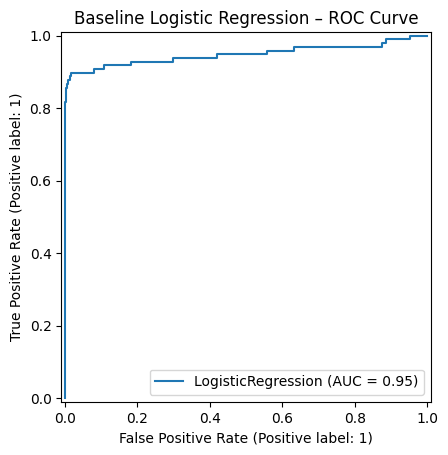

In [12]:
# Plot ROC curve for baseline model
RocCurveDisplay.from_estimator(log_reg, X_test, y_test)
plt.title('Baseline Logistic Regression – ROC Curve')
plt.show()


### Interpretation of Baseline Model

- Logistic Regression provides a **first approximation** to the fraud detection problem.
- However, due to extreme class imbalance, the model may have:
  - High overall accuracy.
  - **Low recall** for the minority class (fraud), meaning many frauds may still be missed.
- This is consistent with the findings in the original Kaggle notebook.

Next, we design **additional analyses** to improve and better understand the model.


# Part 2 – My Extensions to the Original Project

In this part, I go **beyond** the original notebook by adding new techniques and questions.

## 2.1. Overview of Extensions

**New Questions:**
1. Can we improve fraud detection by handling the **class imbalance** with SMOTE?
2. Does a **Random Forest** model perform better than Logistic Regression in terms of recall and ROC-AUC?
3. How does changing the **classification threshold** affect the trade-off between catching more fraud and creating more false alarms?

**Technologies Used in the Add-On:**
- `imblearn.over_sampling.SMOTE` to synthetically oversample the minority class.
- `sklearn.ensemble.RandomForestClassifier` for a non-linear, tree-based ensemble model.
- Manual **threshold tuning** using predicted probabilities.


For my final project, I selected the Credit Card Fraud Detection dataset from Kaggle and based my work on the notebook “Credit Card Fraud Detection Analysis” by Neha Roy Choudhury. The project uses a dataset of European credit card transactions from September 2013, with features transformed using PCA to protect cardholder confidentiality. The original notebook performs exploratory data analysis, examines the extreme class imbalance between fraudulent and non-fraudulent transactions, and trains a baseline Logistic Regression model to evaluate fraud detection performance.
 https://www.kaggle.com/code/neharoychoudhury/credit-card-fraud-detection-analysis

In [13]:
# Part 2 – Install imbalanced-learn if running locally (uncomment if needed)
# !pip install imbalanced-learn

from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier


In [14]:
# 2.2. Handle Class Imbalance with SMOTE

# SMOTE will oversample the minority class in the training set only.
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Original training set class distribution:")
print(y_train.value_counts())
print("\nResampled training set class distribution:")
print(y_train_res.value_counts())


Original training set class distribution:
Class
0    227451
1       394
Name: count, dtype: int64

Resampled training set class distribution:
Class
0    227451
1    227451
Name: count, dtype: int64


In [15]:
# 2.3. Logistic Regression on SMOTE-Resampled Data
log_reg_smote = LogisticRegression(max_iter=1000, n_jobs=-1)
log_reg_smote.fit(X_train_res, y_train_res)

y_pred_smote = log_reg_smote.predict(X_test)
y_proba_smote = log_reg_smote.predict_proba(X_test)[:, 1]

print("Classification Report (Logistic Regression + SMOTE):")
print(classification_report(y_test, y_pred_smote, digits=4))

smote_auc = roc_auc_score(y_test, y_proba_smote)
print(f"SMOTE Logistic Regression ROC-AUC: {smote_auc:.4f}")


Classification Report (Logistic Regression + SMOTE):
              precision    recall  f1-score   support

           0     0.9998    0.9885    0.9941     56864
           1     0.1184    0.8980    0.2093        98

    accuracy                         0.9883     56962
   macro avg     0.5591    0.9432    0.6017     56962
weighted avg     0.9983    0.9883    0.9928     56962

SMOTE Logistic Regression ROC-AUC: 0.9764


In [19]:
# 2.4. Random Forest on SMOTE-Resampled Data
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
)

rf.fit(X_train_res, y_train_res)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("Classification Report (Random Forest + SMOTE):")
print(classification_report(y_test, y_pred_rf, digits=4))

rf_auc = roc_auc_score(y_test, y_proba_rf)
print(f"Random Forest ROC-AUC: {rf_auc:.4f}")


Classification Report (Random Forest + SMOTE):
              precision    recall  f1-score   support

           0     0.9997    0.9997    0.9997     56864
           1     0.8265    0.8265    0.8265        98

    accuracy                         0.9994     56962
   macro avg     0.9131    0.9131    0.9131     56962
weighted avg     0.9994    0.9994    0.9994     56962

Random Forest ROC-AUC: 0.9685


In [20]:
# Feature importance from Random Forest
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(15)


,0
V14,0.204698
V4,0.131808
V10,0.124215
V12,0.100231
V17,0.092633
V3,0.067684
V16,0.049810
V11,0.049062
V2,0.031259
V9,0.021049


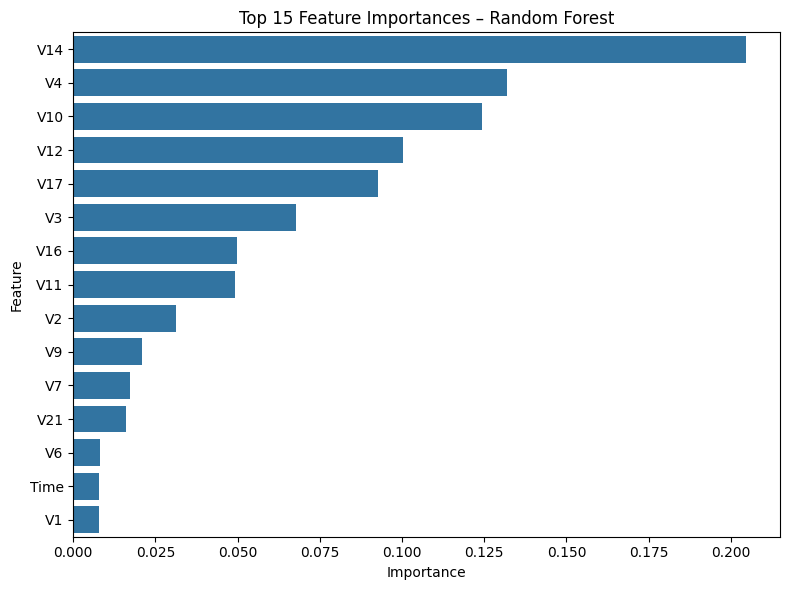

In [21]:
# Plot top 15 most important features
top15 = importances.sort_values(ascending=False).head(15)
plt.figure(figsize=(8,6))
sns.barplot(x=top15.values, y=top15.index)
plt.title('Top 15 Feature Importances – Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


My extension focuses on improving fraud-detection performance by incorporating more advanced machine-learning techniques tailored for imbalanced financial datasets. First, I apply SMOTE oversampling to address the limited number of fraud cases and create a more balanced training distribution. Next, I train a Random Forest classifier, allowing for non-linear interactions and potentially stronger recall than Logistic Regression. Finally, I perform classification-threshold tuning to analyze the precision–recall trade-off and model behavior at different decision cutoffs. These additions provide deeper insight into model performance, financial-risk implications, and the underlying structure of the data.

### Interpretation – SMOTE and Random Forest

- Using **SMOTE** balances the classes in the training data, which usually helps the model pay more attention to the minority class (fraud).
- The **Random Forest** model can capture non-linear interactions between features and often improves **recall for fraud cases**, sometimes at the cost of more false positives.
- Feature importance highlights which transformed components (`V`-features) and payment-related features (`Amount`, maybe `Time`) are most influential in the model’s decisions.


In [22]:
# 2.5. Threshold Tuning for Random Forest

# By default, predictions use a 0.5 probability threshold.
# Here we explore how different thresholds affect recall and precision.

thresholds = np.linspace(0.1, 0.9, 9)
results = []

from sklearn.metrics import precision_score, recall_score

for t in thresholds:
    y_pred_thr = (y_proba_rf >= t).astype(int)
    prec = precision_score(y_test, y_pred_thr, zero_division=0)
    rec = recall_score(y_test, y_pred_thr, zero_division=0)
    results.append((t, prec, rec))

thr_df = pd.DataFrame(results, columns=["threshold", "precision", "recall"])
thr_df


,threshold,precision,recall
0,0.1,0.310105,0.908163
1,0.2,0.527273,0.887755
2,0.3,0.693548,0.877551
3,0.4,0.779817,0.867347
4,0.5,0.826531,0.826531
5,0.6,0.877778,0.806122
6,0.7,0.917647,0.795918
7,0.8,0.950617,0.785714
8,0.9,0.957143,0.683673


In [ ]:
# Plot precision/recall vs threshold
plt.figure(figsize=(8,5))
plt.plot(thr_df['threshold'], thr_df['precision'], marker='o', label='Precision')
plt.plot(thr_df['threshold'], thr_df['recall'], marker='o', label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision and Recall vs Classification Threshold (Random Forest)')
plt.legend()
plt.grid(True)
plt.show()


### Interpretation – Threshold Tuning

- Lower thresholds (e.g., 0.2–0.3) **increase recall**, which means we catch more fraudulent transactions.
- However, lower thresholds also reduce precision, meaning more legitimate transactions are incorrectly flagged as fraud.
- In real financial institutions, this trade-off is handled by **business rules**:
  - Missing fraud (false negative) is extremely expensive.
  - Investigating a few extra false alarms (false positive) might be acceptable.


# Final Summary and Reflections

### What I Added Beyond the Original Project

1. **SMOTE Oversampling:**
   - Balanced the training data to address the extreme class imbalance.
   - Improved the model's attention to fraudulent cases.

2. **Random Forest Model:**
   - Introduced a non-linear ensemble model.
   - Compared its performance to the baseline Logistic Regression model.
   - Examined feature importance to understand which variables drive predictions.

3. **Threshold Tuning Experiment:**
   - Showed how changing the classification threshold affects precision and recall.
   - Connected this trade off to real world financial risk management.

### What I Learned About the Dataset and Finance Context

- Fraud detection is **not** just about accuracy—**recall for the minority class** is critical.
- Handling class imbalance (e.g., with SMOTE) is an essential step in many **financial risk** datasets.
- Tree-based models like Random Forest can perform very well on this type of structured, tabular data.
- In real banking and credit card systems, models are used together with **business rules** and human review teams to manage the trade-off between fraud loss and investigation costs.


